# Applied Machine Learning - Final Project 
## Applied Machine Learning for a FinTech Startup

##### Context 

### 1. Data Exploration

#### - Library Importation

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#### - Data Loading from UCI Repository

In [9]:
df = pd.read_csv("UCI_Credit_Card.csv")

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [10]:
print("Dataset shape is:", df.shape)
print(" * Dataset Information * ")
print(df.info())

Dataset shape is: (30000, 25)
 * Dataset Information * 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   3000

#### • Check Missing Values

In [12]:
print("Check Missing Values:")
print("                           * NaN * ")
print(df.isna().sum())

Check Missing Values:
                           * NaN * 
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


#### • Removal of non-informative features

In [14]:
#  Drop ID Column

df.drop(columns=["ID"], inplace=True)

#### •	Handling invalid categorical values

In [16]:
# Fix EDUCATION Variable

df["EDUCATION"] = df["EDUCATION"].replace([5, 6], 4)
df["EDUCATION"].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      454
0       14
Name: count, dtype: int64

In [17]:
# Fix MARRIAGE Variable

df["MARRIAGE"] = df["MARRIAGE"].replace(0, 3)
df["MARRIAGE"].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

#### • Short Exploratory Data Analysis (EDA)

In [19]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.840400,1.557267,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.744097,0.521405,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [27]:
# Target Variable Distribution
#	1 = Default (non-payment)
#	0 = No default

target = "default.payment.next.month"
df[target].value_counts(normalize=True)

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

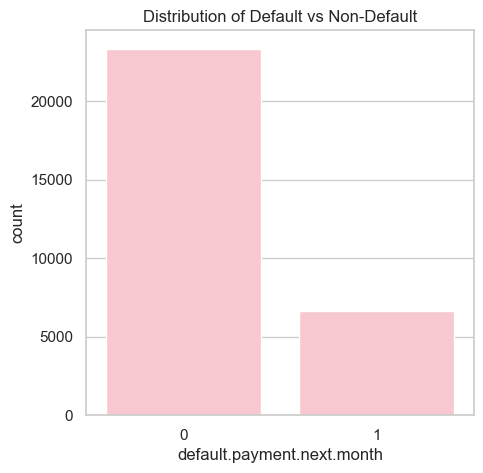

In [32]:
plt.figure(figsize=(5,5))
sns.countplot(x=target, data=df, color = "pink")
plt.title("Distribution of Default vs Non-Default")
plt.show()

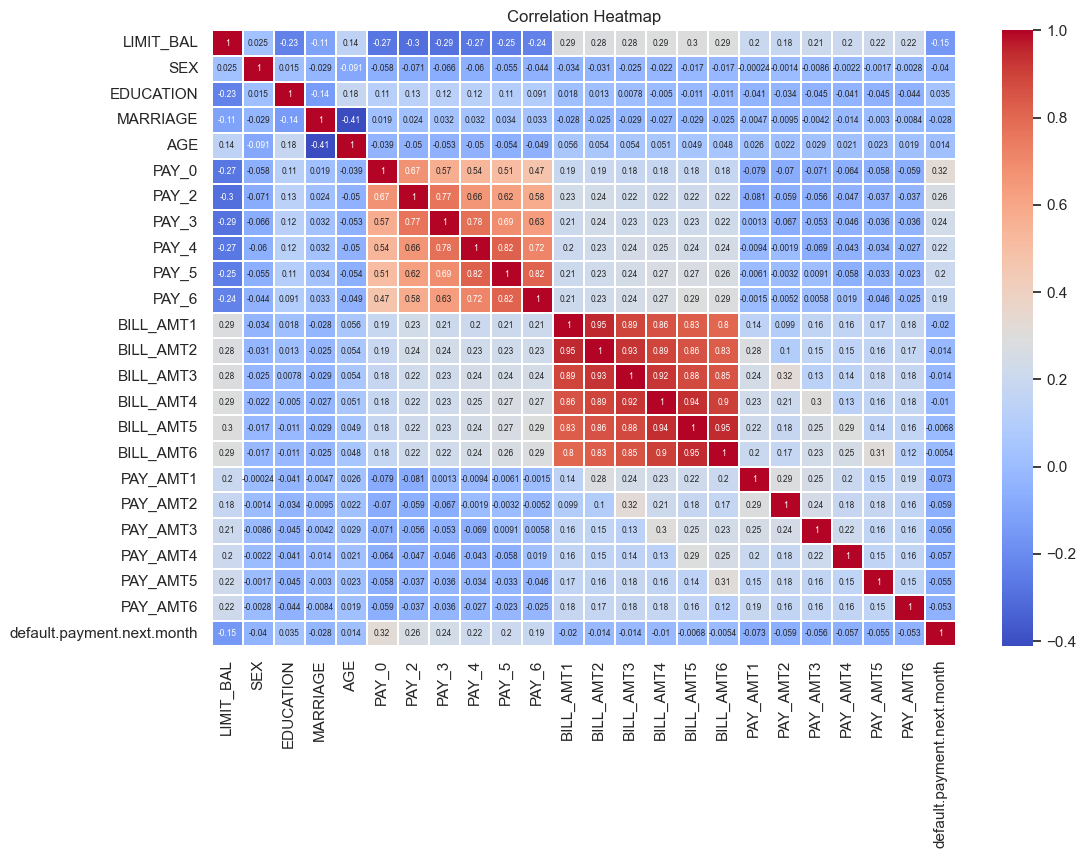

In [34]:
#   Correlation Analysis

plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=True, linewidths=0.3, annot_kws={"size": 6})
plt.title("Correlation Heatmap")
plt.show()

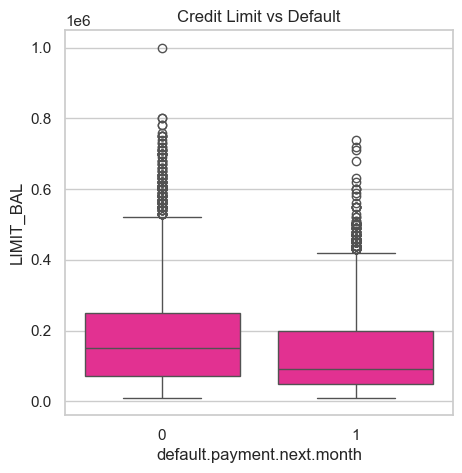

In [35]:
#  Key Feature vs Target Example
# =========================
plt.figure(figsize=(5,5))
sns.boxplot(x=target, y="LIMIT_BAL", data=df, color = "deeppink")
plt.title("Credit Limit vs Default")
plt.show()

### 2. Feature Engineering

In [37]:
# Billing and Payment Columns

bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
delay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Average Spending and Payments

df["avg_bill_amt"] = df[bill_cols].mean(axis=1)
df["avg_pay_amt"] = df[pay_cols].mean(axis=1)

# Payment Ratio

df["payment_ratio"] = df["avg_pay_amt"] / (df["avg_bill_amt"] + 1)

# Credit Utilisation

df["credit_utilization"] = df["avg_bill_amt"] / df["LIMIT_BAL"]

# Repayment Delay Features

df["max_delay"] = df[delay_cols].max(axis=1)
df["avg_delay"] = df[delay_cols].mean(axis=1)

# Debt Trend

df["debt_trend"] = df["BILL_AMT1"] - df["BILL_AMT6"]

In [38]:
# Check NaN values

df.isnull().sum().sort_values(ascending=False).head(10)

payment_ratio                 2
LIMIT_BAL                     0
BILL_AMT6                     0
avg_delay                     0
max_delay                     0
credit_utilization            0
avg_pay_amt                   0
avg_bill_amt                  0
default.payment.next.month    0
PAY_AMT6                      0
dtype: int64

In [39]:
# Handle NaN values

df["credit_utilization"] = (
    df["credit_utilization"]
    .replace([np.inf, -np.inf], np.nan)
)

df["credit_utilization"] = (
    df["credit_utilization"]
    .fillna(df["credit_utilization"].median())
)

df["payment_ratio"] = (
    df["payment_ratio"]
    .fillna(df["payment_ratio"].median())
)

In [41]:
df.isnull().sum().sum()

0

In [47]:
# New Features
df[[
    "avg_bill_amt",
    "avg_pay_amt",
    "payment_ratio",
    "credit_utilization",
    "max_delay",
    "avg_delay",
    "debt_trend"
]].describe()

,avg_bill_amt,avg_pay_amt,payment_ratio,credit_utilization,max_delay,avg_delay,debt_trend
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,44976.945200,5275.232094,3.765715,0.373048,0.438733,-0.182439,12351.570500
std,63260.721860,10137.946323,209.643984,0.351890,1.345154,0.982176,43922.421534
min,-56043.166667,0.000000,-1502.000000,-0.232590,-2.000000,-2.000000,-428791.000000
25%,4781.333333,1113.291667,0.041075,0.029997,0.000000,-0.833333,-2963.000000
50%,21051.833333,2397.166667,0.086201,0.284834,0.000000,0.000000,923.000000
75%,57104.416667,5583.916667,0.597965,0.687929,2.000000,0.000000,19793.750000
max,877313.833333,627344.333333,27000.000000,5.364308,8.000000,6.000000,708323.000000


### 2. Model Development 

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#  Define Features and Target

target = "default.payment.next.month"
X = df.drop(columns=[target])
y = df[target]

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
#  Primary Model: Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [52]:
# Scale Features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline Model: Logistic Regression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

### 3. Evaluation 

In [54]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, roc_auc_score

#### • Classification Report

In [57]:
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4673
           1       0.51      0.57      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.79      6000


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.35      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



#### • Model Performance

In [59]:
performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score", "ROC-AUC"],
    "Random Forest":       [accuracy_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_prob_rf)],
    "Logistic Regression": [accuracy_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr), roc_auc_score(y_test, y_prob_lr)]
    
})
print("Model Performance:")
performance_df

Model Performance:


,Metric,Random Forest,Logistic Regression
0,Accuracy,0.781667,0.807833
1,F1 Score,0.537429,0.351154
2,ROC-AUC,0.777649,0.724477


This Table summarises the performance of both models across key evaluation metrics. The Random Forest model outperforms the baseline Logistic Regression, particularly in terms of F1-score and ROC-AUC, supporting its selection as the primary model

#### •  Confusion Matrix

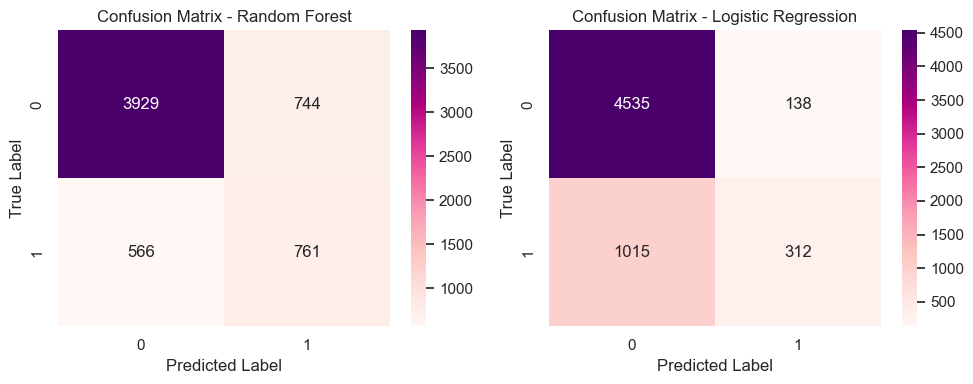

In [62]:
cm_rf = confusion_matrix(y_test, y_pred_rf) # Confusion Matrix - Random Forest
cm_lr = confusion_matrix(y_test, y_pred_lr) # Confusion Matrix - Logistic Regression

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Random Forest
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='RdPu',
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix - Random Forest")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Logistic Regression
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='RdPu',
    ax=axes[1]
)
axes[1].set_title("Confusion Matrix - Logistic Regression")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

Separate confusion matrices and ROC curves were generated for each model to ensure a fair and transparent comparison between the baseline Logistic Regression and the primary Random Forest model.

#### • ROC Curve


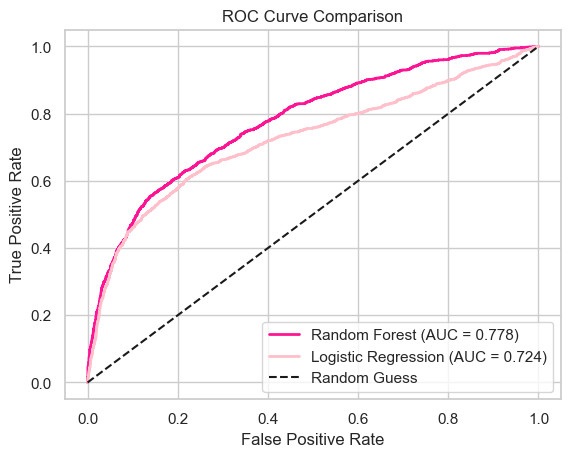

In [65]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})", linewidth=2, color='deeppink')
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})", linewidth=2, color='pink')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The Random Forest model demonstrates superior discriminatory power, as reflected by its higher ROC-AUC and improved recall for default cases.

### 4. SHAP explainability

In [68]:
 pip install shap

Note: you may need to restart the kernel to use updated packages.


In [69]:
import shap

####  • setting up the explainer

In [71]:
# SHAP explainer for Random Forest

explainer = shap.TreeExplainer(rf)


# Sample for efficiency
X_sample = X_test.sample(500, random_state=42)

shap_values = explainer.shap_values(X_sample)

Note: SHAP values were computed on a representative subset of the test data to improve computational efficiency while preserving the interpretability and reliability of global and local explanations.

In [73]:
classes = getattr(rf, "classes_", None)

if classes is not None and len(classes) > 1:
    pos_idx = list(classes).index(1)
else:
    pos_idx = 0


if isinstance(shap_values, list):
    sv = shap_values[pos_idx]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, pos_idx]
else:
    sv = shap_values

####  • Global Explainability — Summary Plot

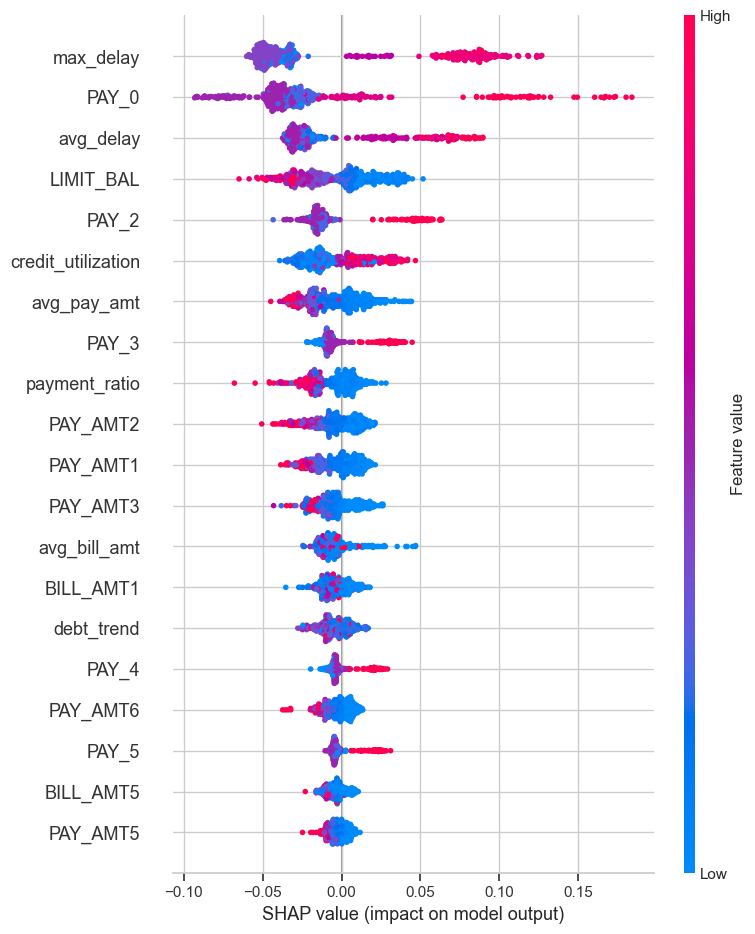

In [75]:
shap.summary_plot(
    sv,
    X_sample.values,
    feature_names=X_sample.columns
)

####  • Dependence plot

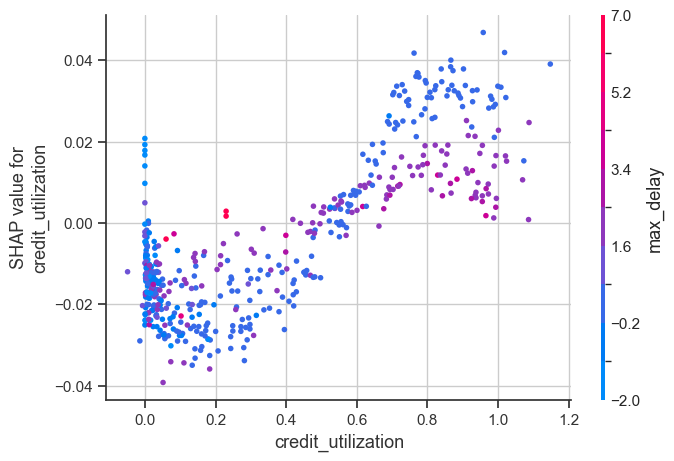

In [77]:
shap.dependence_plot(
    "credit_utilization",
    sv,
    X_sample.values,
    feature_names=X_sample.columns
)

####  • Local Explainability — Force Plot

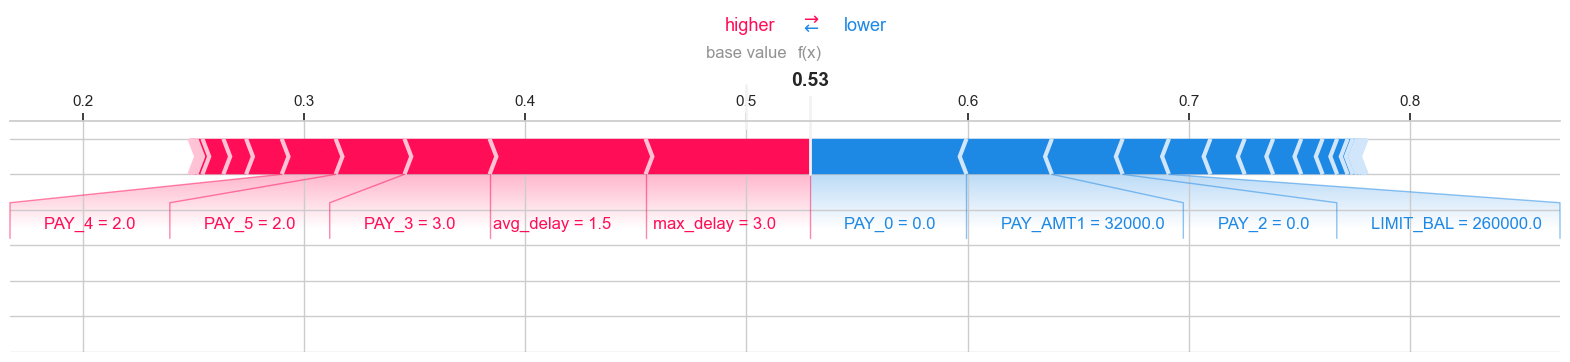

In [79]:
i = 0

base_val = (
    explainer.expected_value[pos_idx]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

shap.plots.force(
    base_val,
    sv[i, :],
    X_sample.iloc[i, :].values,
    feature_names=X_sample.columns,
    matplotlib=True
)

####  • Decision Plot

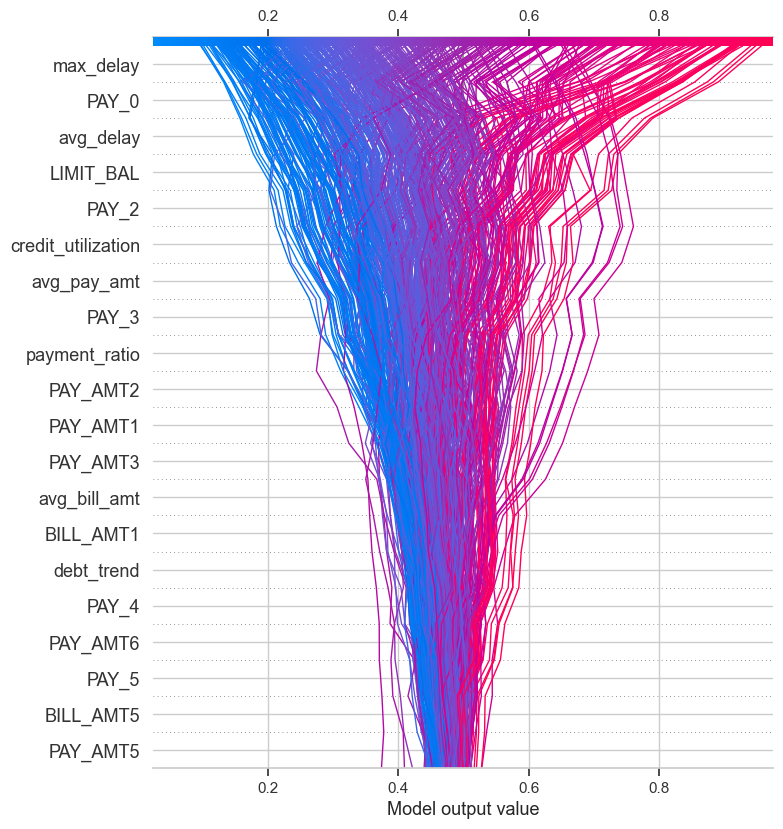

In [81]:
shap.decision_plot(
    base_val,
    sv,
    feature_names=list(X_sample.columns)
)